In [ ]:
npy_file = r"D:\LongTermStorage\Pipeline_Testing\ColibriArchive\2024-10-19\20241020_02.12.30.710_stars.npy"

# read the npy file
import numpy as np
import os
import matplotlib.pyplot as plt

data = np.load(npy_file, allow_pickle=True)
print(data.shape)

[1.72939035e+09 1.72939035e+09 1.72939035e+09 ... 1.72939041e+09
 1.72939041e+09 1.72939041e+09]


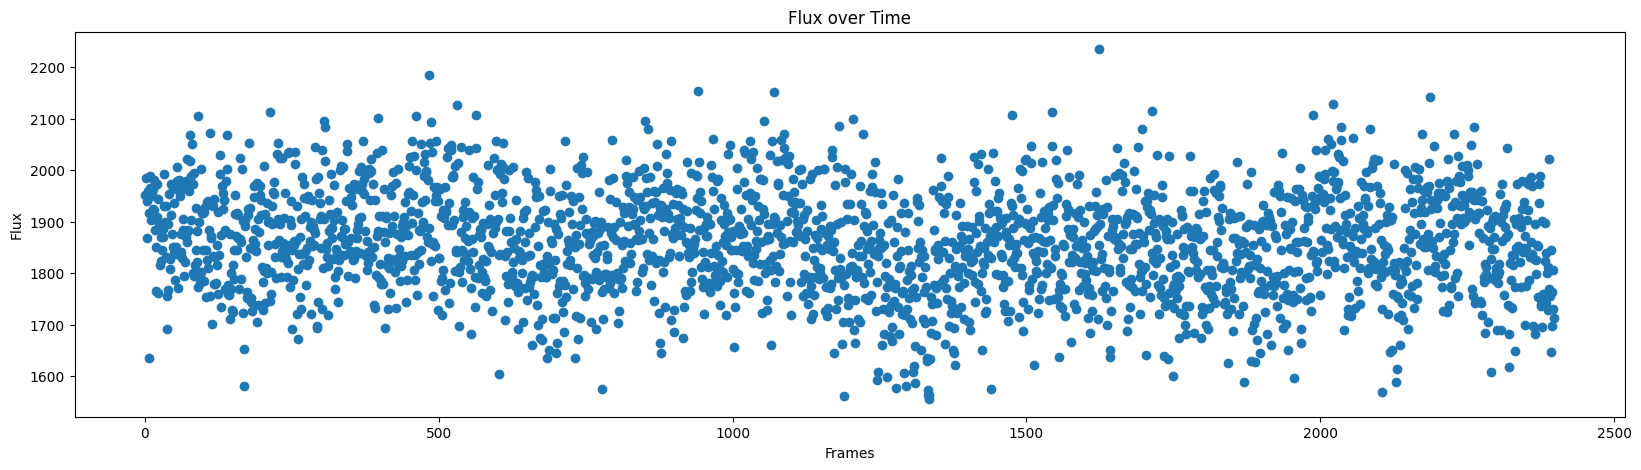

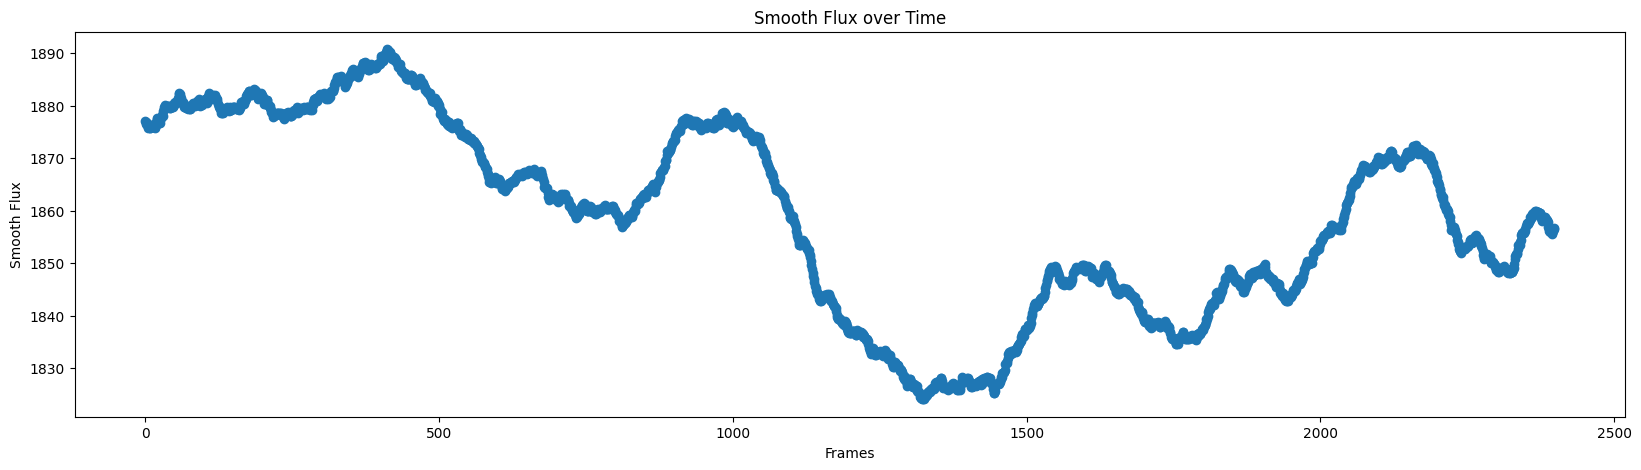

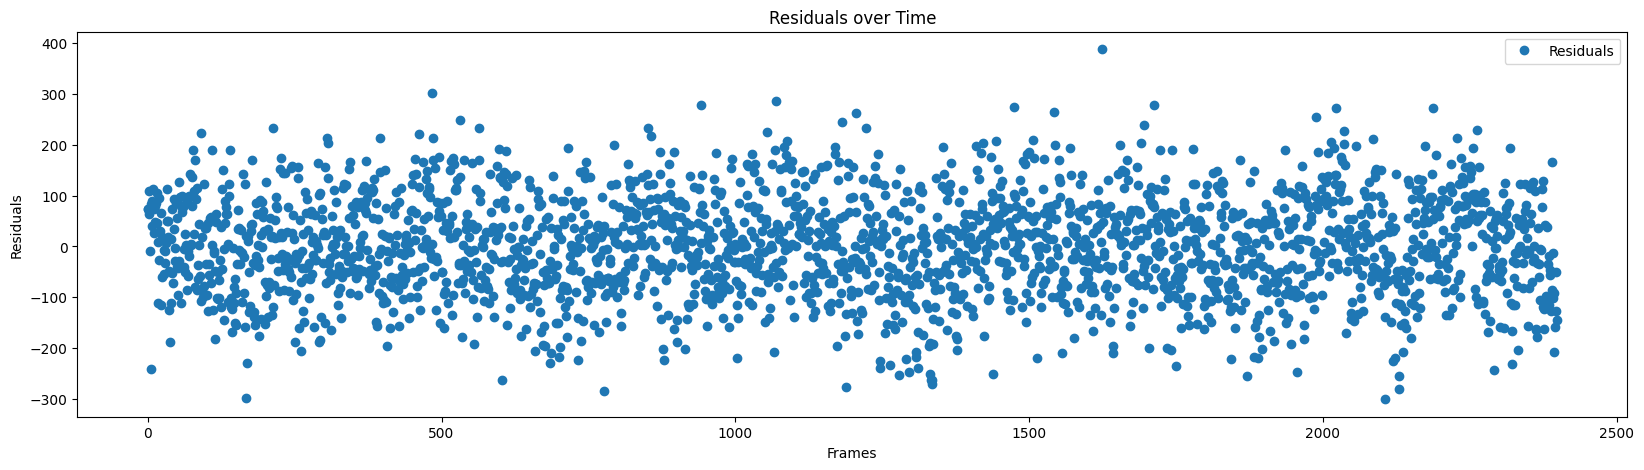

0.2
2335
2399


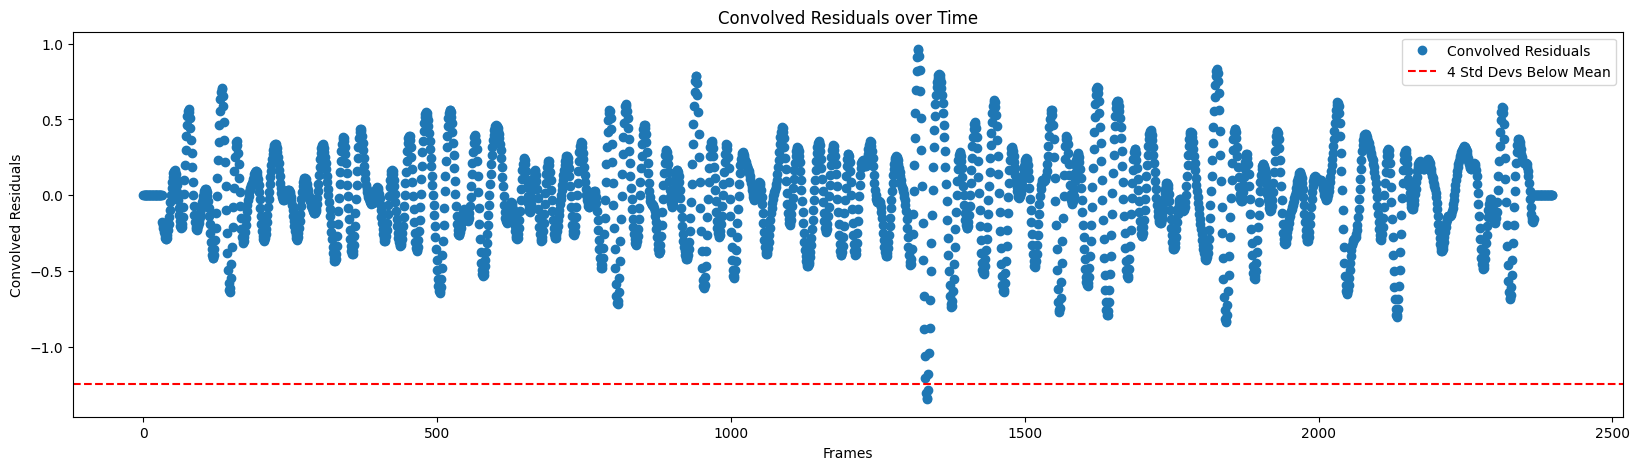

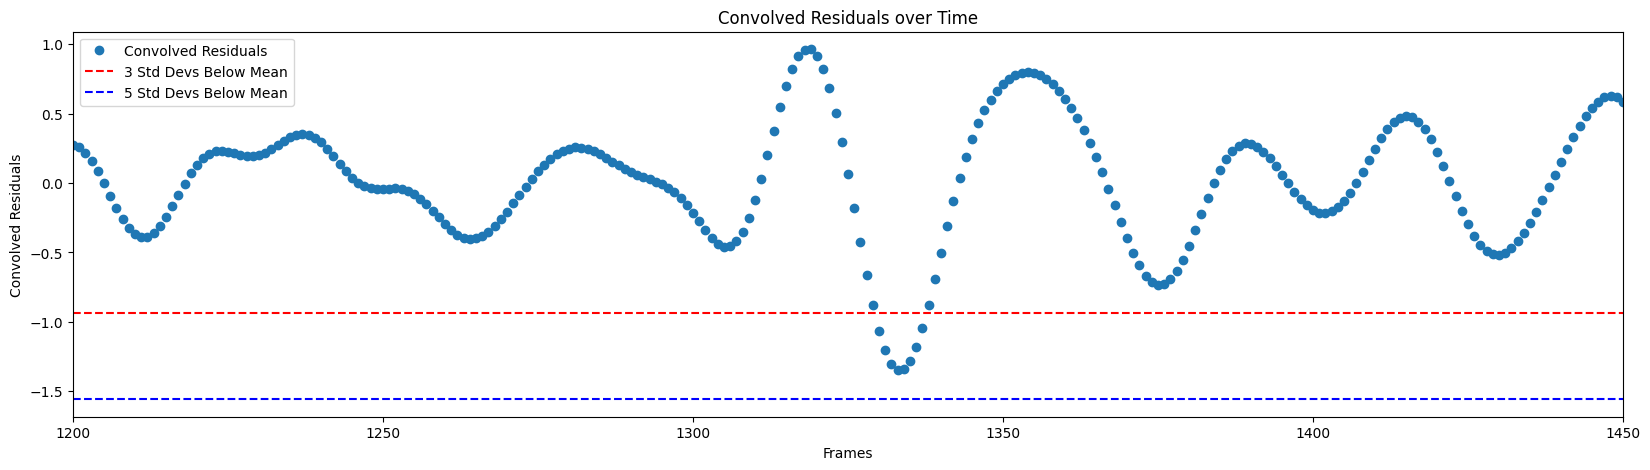

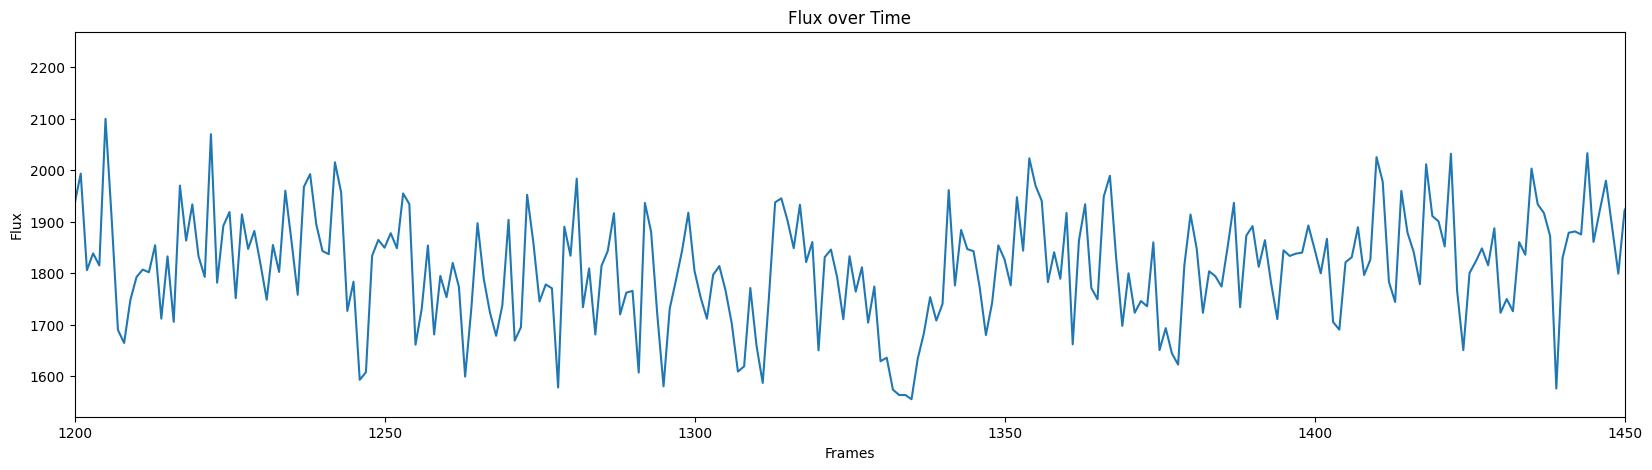

In [58]:
# first dimension is frame, second dim is star, third is [x, y, flux, time]
print(data[:, 0, 3])

time = data[:, 0, 3]
flux = data[:, 0, 2]

frames = range(len(flux))
# plot the flux over time
fig = plt.figure(figsize=(20, 5))
plt.plot(frames, flux, 'o')
plt.xlabel('Frames')
plt.ylabel('Flux')
plt.title('Flux over Time')
plt.show()

# mean smooth the flux using a filter
from scipy.ndimage import uniform_filter1d

smoothed_flux = uniform_filter1d(flux, size=40*10, mode='reflect')

fig = plt.figure(figsize=(20, 5))
plt.plot(frames, smoothed_flux, 'o')
plt.xlabel('Frames')
plt.ylabel('Smooth Flux')
plt.title('Smooth Flux over Time')
plt.show()

residuals = flux - smoothed_flux
fig = plt.figure(figsize=(20, 5))
plt.plot(frames, residuals, 'o', label='Residuals')
plt.xlabel('Frames')
plt.ylabel('Residuals')
plt.title('Residuals over Time')
plt.legend()
plt.show()

# convolve the residuals with a ricker wavelet
from scipy.signal import convolve
from astropy.convolution import RickerWavelet1DKernel



exposure_time = 0.025    # exposure length in seconds
expected_length = 8*exposure_time   # related to the characteristic scale length, length of signal to boost in convolution, may need tweaking/optimizing
print(round(expected_length, 3))
# expected_length = 0.15

kernel_frames = int(round(expected_length / exposure_time))   # width of kernel
ricker_kernel = RickerWavelet1DKernel(kernel_frames)          # generate kernel

conv = convolve(residuals, ricker_kernel, mode='valid')    #convolution of light curve with Ricker wavelet
# Calculate the number of zeros to add on each side
padding_length = (len(flux) - len(conv)) // 2

mean_conv = np.mean(conv)  # mean of the convolved residuals
std_conv = np.std(conv)  # standard deviation of the convolved residuals

# Create arrays of for padding
padding = np.ones(padding_length) * mean_conv

# Concatenate zeros to the beginning and end of the convolution result
conv_padded = np.concatenate((padding, conv, padding))
print(len(conv))
print(len(conv_padded))



fig = plt.figure(figsize=(20, 5))
plt.plot(frames, conv_padded, 'o', label='Convolved Residuals')
plt.xlabel('Frames')
plt.ylabel('Convolved Residuals')
plt.title('Convolved Residuals over Time')

# plot a horizontal line at 3 std devs below the mean of the convolved residuals
plt.axhline(mean_conv - 4*std_conv, color='red', linestyle='--', label='4 Std Devs Below Mean')
plt.legend()
plt.show()

fig = plt.figure(figsize=(20, 5))
plt.plot(frames, conv_padded, 'o', label='Convolved Residuals')
plt.xlabel('Frames')
plt.ylabel('Convolved Residuals')
plt.title('Convolved Residuals over Time')

# plot a horizontal line at 3 std devs below the mean of the convolved residuals
plt.axhline(mean_conv - 3*std_conv, color='red', linestyle='--', label='3 Std Devs Below Mean')
plt.axhline(mean_conv - 5*std_conv, color='blue', linestyle='--', label='5 Std Devs Below Mean')

plt.legend()
plt.xlim(1200, 1450)
plt.show()



fig = plt.figure(figsize=(20, 5))
plt.plot(frames, flux)
plt.xlabel('Frames')
plt.ylabel('Flux')
plt.title('Flux over Time')
plt.xlim(1200, 1450)
plt.show()




In [9]:
import numpy as np
import os
from datetime import datetime

def readRCD(filename):
    """
    Reads .rcd file
    
        Parameters:
            filename (Path): Path to .rcd file
            
        Returns:
            table (arr): Table with image pixel data
            timestamp (str): Timestamp of observation
    """

    ## Open .rcd file and extract the observation timestamp and data
    with open(filename, 'rb') as fid:
        # Timestamp
        fid.seek(152, 0)
        timestamp = fid.read(29).decode('utf-8')

        # Load data portion of file
        fid.seek(384, 0)
        table = np.fromfile(fid, dtype=np.uint8, count=12582912)

    return table, timestamp

# Test with the file
test = readRCD('D:\\Sensitivity_Measurements_2024\\20240729\\20240729_03.05.55.471\\Alt89.2_25ms-_0000010.rcd')

# Print image data shape and extracted timestamp
print(test[0].shape)
print("rcd time: ", test[1])

# Get the file creation or modification time from Windows
filename = 'D:\\Sensitivity_Measurements_2024\\20240729\\20240729_03.05.55.471\\Alt89.2_25ms-_0000010.rcd'

# Get the modification time of the file (in seconds since the epoch)
file_mod_time = os.path.getmtime(filename)

# Convert to datetime object in UTC
mod_time_utc = datetime.utcfromtimestamp(file_mod_time)

# Format the time in the required format: YYYY-MM-DDThh:mm:ss.dddddddddZ
formatted_mod_time = mod_time_utc.strftime('%Y-%m-%dT%H:%M:%S.') + f'{mod_time_utc.microsecond * 1000:09d}' 

# Print the Windows system modification time
print("Windows file modification time: ", formatted_mod_time)



(12582912,)
rcd time:  2016-00-00T00:35:03.747215425
Windows file modification time:  2024-07-29T03:05:55.790967000


new version

In [1]:
import numpy as np
import os
import datetime

def readRCD(filename):
    """
    Reads .rcd file and Windows file modification time.
    
        Parameters:
            filename (Path): Path to .rcd file
            
        Returns:
            table (arr): Table with image pixel data
            timestamp (str): Timestamp of observation
            file_mod_time (str): File modification time from the system in ISO format
    """

    ## Open .rcd file and extract the observation timestamp and data
    with open(filename, 'rb') as fid:
        # Timestamp from file
        fid.seek(152, 0)
        timestamp = fid.read(29).decode('utf-8')

        # Load data portion of file
        fid.seek(384, 0)
        table = np.fromfile(fid, dtype=np.uint8, count=12582912)

    # Get the file modification time from the Windows system
    file_mod_time_epoch = os.path.getmtime(filename)
    file_mod_time = datetime.datetime.fromtimestamp(file_mod_time_epoch, tz=datetime.timezone.utc)

    # Format the modification time without the 'Z'
    formatted_mod_time = file_mod_time.strftime('%Y-%m-%dT%H:%M:%S.') + f'{file_mod_time.microsecond * 1000:09d}'

    return table, timestamp, formatted_mod_time


# Test with the file
test = readRCD('D:\\Sensitivity_Measurements_2024\\20240729\\20240729_03.05.55.471\\Alt89.2_25ms-_0000010.rcd')

# Print image data shape and extracted timestamp
print(test[0].shape)
print("rcd time: ", test[1])
print("Windows file modification time: ", test[2])

print(type(test[1]))
print(type(test[2]))

(12582912,)
rcd time:  2016-00-00T00:35:03.747215425
Windows file modification time:  2024-07-29T03:05:55.790967000
<class 'str'>
<class 'str'>


new one works! just need to remove returning the original timestamp